In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re
from collections import defaultdict
from __future__ import annotations

In [2]:
def convert_wechem_xlsx_to_csv(folder, subfolders, channels, out_folder_name="wechem_csv", target_len=200):
    out_dir = os.path.join(folder, out_folder_name)
    os.makedirs(out_dir, exist_ok=True)

    files = []
    for sub in subfolders:
        subdir = os.path.join(folder, sub)
        if not os.path.isdir(subdir):
            continue
        for fname in os.listdir(subdir):
            if not fname.lower().endswith(".xlsx"):
                continue
            m = re.match(r"(\d+)_wechem", fname)
            if not m:
                continue
            num = int(m.group(1))
            full_path = os.path.join(subdir, fname)
            files.append((num, full_path))

    files.sort(key=lambda x: x[0])

    header_lines = [
        "Converted from weChem Excel file",
        "Line 2",
        "Line 3",
        "Line 4",
        "Line 5",
        "Line 6"
    ]

    for idx, (_, file_path) in enumerate(files):
        dfs = pd.read_excel(file_path, sheet_name=None)

        volt_raw = 1e-3 * dfs[f"Channel {channels[0]}"]["Voltage [mV]"].to_numpy()
        if volt_raw.ndim != 1 or len(volt_raw) < 2:
            continue

        n_raw = len(volt_raw)
        if n_raw == target_len:
            new_volt = volt_raw
        else:
            new_volt = np.linspace(volt_raw[0], volt_raw[-1], target_len)

        data = {}
        col_order = []

        data["V"] = new_volt
        col_order.append("V")

        for ch in channels:
            df_ch = dfs[f"Channel {ch}"]
            curr_raw = df_ch["Current Fwd-Rev [uA]"].to_numpy()
            if len(curr_raw) != n_raw:
                continue

            if n_raw == target_len:
                curr_resampled = curr_raw
            else:
                curr_resampled = np.interp(new_volt, volt_raw, curr_raw)

            curr_col_name = f"ch{ch}_current"
            dummy_col_name = f"ch{ch}_V"
            data[curr_col_name] = curr_resampled
            data[dummy_col_name] = new_volt
            col_order.extend([curr_col_name, dummy_col_name])

        out_df = pd.DataFrame(data)[col_order]

        if idx == 0:
            out_name = "100hz.csv"
        else:
            out_name = f"100hz-{idx}.csv"
        out_csv = os.path.join(out_dir, out_name)

        with open(out_csv, "w", encoding="utf-16") as f:
            for line in header_lines:
                f.write(line + "\n")
            out_df.to_csv(f, index=False)

In [13]:
folder = '/Users/Max/Soh Lab/echem'
subfolders = ["Animal"]
channels = [1]

convert_wechem_xlsx_to_csv(folder, subfolders, channels)

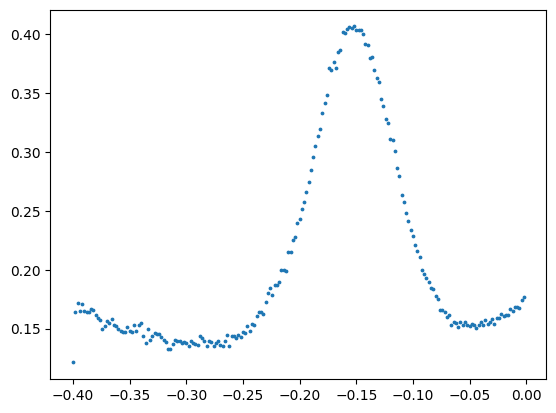

In [8]:
path = '/Users/Max/Soh Lab/echem/weChem Testing/wechem_csv/100hz.csv'
df = pd.read_csv(path, skiprows=6, encoding="utf-16").apply(pd.to_numeric, errors='coerce').dropna()
volts = df.iloc[:, 0].astype(float).to_numpy()
currents = df.iloc[:, 1::2].dropna(how='all').astype(float).to_numpy().T
plt.scatter(volts, currents[0], s=3)
plt.show()

In [3]:
from pathlib import Path
import re

folder = Path("/Users/Max/Soh Lab/echem/M4_60Hz_SWV/01_PreReset")
pattern = re.compile(r"(?i)(\d+)\s*hz-(\d+)\.csv$")

matches = []
for p in folder.glob("*.csv"):
    m = pattern.search(p.name)
    if not m:
        print(f"SKIP (no match): {p.name}")
        continue
    freq = int(m.group(1))
    old_rep = int(m.group(2))
    matches.append((freq, old_rep, p))

matches.sort(key=lambda t: (t[0], t[1]))

plan = []
next_rep_by_freq = {}
for freq, old_rep, p in matches:
    next_rep_by_freq.setdefault(freq, 0)
    next_rep_by_freq[freq] += 1
    new_rep = next_rep_by_freq[freq]
    new_name = f"{freq}hz-{new_rep}.csv"
    plan.append((p, p.with_name(new_name), freq, old_rep, new_rep))

tmp_plan = []
for p, new_path, freq, old_rep, new_rep in plan:
    tmp_path = p.with_name(f"__tmp__{p.name}")
    if tmp_path.exists():
        raise FileExistsError(f"Temp file already exists: {tmp_path}")
    tmp_plan.append((p, tmp_path, new_path))

for src, tmp, _final in tmp_plan:
    src.rename(tmp)

for _src, tmp, final in tmp_plan:
    if final.exists():
        print(f"SKIP (target exists): {final.name} (leaving temp as {tmp.name})")
        continue
    tmp.rename(final)
    print(f"RENAMED: {final.name}")


SKIP (no match): M4_60Hz.csv
RENAMED: 60hz-1.csv
RENAMED: 60hz-2.csv
RENAMED: 60hz-3.csv
RENAMED: 60hz-4.csv
RENAMED: 60hz-5.csv
RENAMED: 60hz-6.csv
RENAMED: 60hz-7.csv
RENAMED: 60hz-8.csv
RENAMED: 60hz-9.csv
RENAMED: 60hz-10.csv
RENAMED: 60hz-11.csv
RENAMED: 60hz-12.csv
RENAMED: 60hz-13.csv
RENAMED: 60hz-14.csv
RENAMED: 60hz-15.csv
RENAMED: 60hz-16.csv
RENAMED: 60hz-17.csv
RENAMED: 60hz-18.csv
RENAMED: 60hz-19.csv
RENAMED: 60hz-20.csv
RENAMED: 60hz-21.csv
RENAMED: 60hz-22.csv
RENAMED: 60hz-23.csv
RENAMED: 60hz-24.csv
RENAMED: 60hz-25.csv
RENAMED: 60hz-26.csv
RENAMED: 60hz-27.csv
RENAMED: 60hz-28.csv
RENAMED: 60hz-29.csv
RENAMED: 60hz-30.csv
RENAMED: 60hz-31.csv
RENAMED: 60hz-32.csv
RENAMED: 60hz-33.csv
RENAMED: 60hz-34.csv
RENAMED: 60hz-35.csv
RENAMED: 60hz-36.csv
RENAMED: 60hz-37.csv
RENAMED: 60hz-38.csv
RENAMED: 60hz-39.csv


In [3]:
def _norm_col(s: str) -> str:
    """Normalize header strings for robust matching (remove whitespace)."""
    return re.sub(r"\s+", "", str(s).strip())


def _parse_echem_txt_table(txt_path: Path) -> pd.DataFrame:
    """
    Parse the main numeric table from a weChem-style .txt file.

    Looks for a header line containing 'Potential/V' and comma-separated columns like:
      Potential/V, i1d/A, i1f/A, i1r/A, i2d/A, ...

    Handles:
      - blank line(s) after header
      - stops at section labels like 'Forward:' / 'Reverse:' / etc.
    """
    text = txt_path.read_text(encoding="utf-8", errors="replace")
    lines = text.splitlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Potential/V" in line and "," in line:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find table header line containing 'Potential/V' in {txt_path.name}")

    headers = [h.strip() for h in lines[header_idx].strip().split(",")]

    float_start = re.compile(r"^\s*[-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?\s*(,|$)")

    data_rows: list[list[str]] = []
    started = False

    for line in lines[header_idx + 1 :]:
        s = line.strip()

        if not s:
            continue

        # Stop at section labels like "Forward:" / "Reverse:" / "Difference:"
        if re.match(r"^[A-Za-z].*:\s*$", s):
            break

        if float_start.match(s) and ("," in s):
            started = True
            parts = [p.strip() for p in s.split(",")]
            if len(parts) != len(headers):
                continue
            data_rows.append(parts)
        else:
            if started:
                break
            continue

    if not data_rows:
        raise ValueError(f"Found table header but no data rows in {txt_path.name}")

    arr = np.array(data_rows, dtype=float)
    return pd.DataFrame(arr, columns=headers)


def convert_txt_to_csv(
    folder: str | Path,
    out_folder: str | Path,
    encoding_out: str = "utf-16",
) -> None:
    """
    Convert E1_[frequency]Hz__[num].txt files into CSVs in an explicit output folder.

    - Parses the table containing Potential/V and per-channel currents.
    - Uses ONLY difference current columns i{n}d/A (arbitrary number of channels).
    - Writes CSV with alternating headers: V, A, V, A, ... (ends with A),
      duplicating the voltage column per channel to match your required format.
    - Uses the native number of rows in each file (no resampling).

    Output filenames:
      - if num == 1:  {frequency}hz.csv
      - else:         {frequency}hz-{num-1}.csv
    """
    folder = Path(folder)
    out_dir = Path(out_folder).expanduser().resolve()
    out_dir.mkdir(parents=True, exist_ok=True)

    pat = re.compile(r"^E1_(\d+(?:\.\d+)?)\s*Hz__([0-9]+)\.txt$", re.IGNORECASE)

    header_lines = [
        "Converted from weChem TXT file",
        "Line 2",
        "Line 3",
        "Line 4",
        "Line 5",
        "Line 6",
    ]

    files: list[tuple[float, int, Path]] = []
    for p in folder.glob("E1_*Hz__*.txt"):
        m = pat.match(p.name)
        if not m:
            continue
        freq = float(m.group(1))
        num = int(m.group(2))
        files.append((freq, num, p))

    files.sort(key=lambda x: (x[0], x[1]))
    if not files:
        raise FileNotFoundError(f"No matching files found in {folder} (pattern: E1_[freq]Hz__[num].txt)")

    for freq, num, txt_path in files:
        df = _parse_echem_txt_table(txt_path)

        # Map normalized -> original names to tolerate whitespace variants
        norm_to_orig: dict[str, str] = {}
        for c in df.columns:
            norm_to_orig[_norm_col(c)] = c

        # Locate Potential/V robustly
        pot_col = None
        for norm_name, orig_name in norm_to_orig.items():
            if _norm_col(norm_name).lower() == "potential/v":
                pot_col = orig_name
                break
        if pot_col is None:
            raise ValueError(f"Could not find 'Potential/V' in {txt_path.name}. Columns: {list(df.columns)}")

        volt = df[pot_col].to_numpy()
        if volt.ndim != 1 or volt.size < 2:
            continue

        # Locate all i{n}d/A columns robustly
        ch_ids: list[int] = []
        ch_to_col: dict[int, str] = {}
        for norm_name, orig_name in norm_to_orig.items():
            m = re.fullmatch(r"i(\d+)d/A", _norm_col(norm_name))
            if m:
                ch = int(m.group(1))
                ch_ids.append(ch)
                ch_to_col[ch] = orig_name

        ch_ids = sorted(set(ch_ids))
        if not ch_ids:
            raise ValueError(f"No difference-current columns like i1d/A found in {txt_path.name}. Columns: {list(df.columns)}")

        # Build output: V, A, V, A, ... (duplicate V per channel)
        cols: list[str] = []
        arrays: list[np.ndarray] = []

        for ch in ch_ids:
            curr = 10**6 * df[ch_to_col[ch]].to_numpy()
            if curr.size != volt.size:
                continue

            cols.extend(["V", "A"])
            arrays.extend([volt, curr])

        if not arrays:
            continue

        out_df = pd.DataFrame(np.column_stack(arrays), columns=cols)

        # Output name
        freq_out = int(freq) if float(freq).is_integer() else freq
        base = f"{freq_out}hz"
        out_name = f"{base}.csv" if num == 1 else f"{base}-{num-1}.csv"
        out_csv = out_dir / out_name

        with open(out_csv, "w", encoding=encoding_out, newline="") as f:
            for line in header_lines:
                f.write(line + "\n")
            out_df.to_csv(f, index=False)


In [5]:
load_folder = '/Users/Max_1/Soh Lab/echem/Plaxco Multi-Gaussian Data/013023 dox'
out_folder = load_folder + ' scaled csv'
convert_txt_to_csv(folder=load_folder, out_folder=out_folder)

In [6]:
HZ_CYCLE = [10, 200]

def parse_filename(fname: str):
    """
    Parse: Dox_E{int1}_{float}_-{int2}.csv
    int2 may be blank -> treated as 0.
    Returns (float_value, int2_value) or None if not matching.
    """
    pattern = r"Dox_E\d+_([\d\.]+)_-?(\d*)\.csv"
    m = re.match(pattern, fname)
    if not m:
        return None
    float_val = float(m.group(1))
    int2_str = m.group(2)
    int2_val = int(int2_str) if int2_str != "" else 0
    return float_val, int2_val

def hz_and_rep(int2: int):
    """
    Repeating cycle over HZ_CYCLE by int2%5, with rep = floor(int2/5)+1.
    """
    hz = HZ_CYCLE[int2 % 5]
    rep = (int2 // 5) + 1
    return hz, rep

def rename_files(folder_path: str, dry_run: bool = True):
    folder = Path(folder_path)
    files = list(folder.glob("Dox_E*.csv"))

    parsed = []
    for f in files:
        out = parse_filename(f.name)
        if out is None:
            continue
        float_val, int2_val = out
        parsed.append((f, float_val, int2_val))

    if not parsed:
        print("No matching files found.")
        return

    # Sort floats and build float rank
    unique_floats = sorted({fv for _, fv, _ in parsed})

    # For EACH float, find how many reps it actually has (max rep observed at that float)
    reps_count = {fv: 0 for fv in unique_floats}
    for _, fv, int2 in parsed:
        _, rep = hz_and_rep(int2)
        reps_count[fv] = max(reps_count[fv], rep)

    # Build cumulative start index per float (this is the key fix)
    start_index = {}
    running = 1
    for fv in unique_floats:
        start_index[fv] = running
        running += reps_count[fv]

    # Process files in deterministic order: float asc then int2 asc
    parsed.sort(key=lambda x: (x[1], x[2]))

    planned = []
    for f, fv, int2 in parsed:
        hz, rep = hz_and_rep(int2)

        # Optional guard: if you ever want to clamp to exactly reps_count[fv]
        if rep > reps_count[fv]:
            print(f"SKIP (rep>{reps_count[fv]} at float={fv}): {f.name}")
            continue

        new_index = start_index[fv] + rep - 1
        new_name = f"{hz}hz-{new_index}.csv"  # 2-digit formatting
        planned.append((f, f.with_name(new_name)))

    # Collision check
    targets = [dst.name for _, dst in planned]
    if len(set(targets)) != len(targets):
        raise RuntimeError("Name collision detected in planned renames. Aborting.")

    # Execute (or dry-run)
    for src, dst in planned:
        print(f"{src.name}  ->  {dst.name}")
        if not dry_run:
            if dst.exists() and dst.resolve() != src.resolve():
                raise FileExistsError(f"Refusing to overwrite existing file: {dst}")
            src.rename(dst)


In [7]:
for i in np.arange(1, 13, 1):
    path = f'/Users/Max/Soh Lab/echem/20260213_Dox_BC/CH{i:02d}'
    rename_files(path, dry_run=False)

No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.
No matching files found.


In [8]:
HZ_CYCLE = [10, 200]

def hz_and_rep(int2: int):
    hz = HZ_CYCLE[int2 % 5]
    rep = (int2 // 5) + 1
    return hz, rep

def parse_rt0_int2(fname: str):
    """
    Match RT0 files in a single CH folder:

      Dox_E06_RT0_.csv        -> int2 = 0
      Dox_E06_RT0_-21.csv     -> int2 = 21

    Returns int2 (int) or None if not RT0 match.
    """
    # Handles both suffixes: "_" (blank) and "_-NN"
    m = re.match(r"^Dox_E\d+_RT0_(?:\.csv|-([0-9]+)\.csv)$", fname)
    if not m:
        return None
    return 0 if m.group(1) is None else int(m.group(1))

def rename_rt0_files(folder_path: str | Path,
                     start_at: int = 46,
                     dry_run: bool = True):
    """
    Rename RT0 files inside ONE folder (e.g. .../CH06):

      Dox_E??_RT0_.csv, Dox_E??_RT0_-N.csv  ->  {hz}hz-{index:02d}.csv

    Indexing:
      rep = floor(int2/5)+1
      index = start_at + rep - 1

    Hz cycles by int2 % 5 through [10,100,200,500,700].
    """
    folder = Path(folder_path)
    files = list(folder.glob("Dox_E*_RT0_*.csv"))

    parsed = []
    for f in files:
        int2 = parse_rt0_int2(f.name)
        if int2 is None:
            continue
        parsed.append((f, int2))

    if not parsed:
        print(f"[{folder.name}] No RT0 files found.")
        return

    # deterministic order
    parsed.sort(key=lambda x: x[1])

    planned = []
    for f, int2 in parsed:
        hz, rep = hz_and_rep(int2)
        new_index = start_at + rep - 1
        new_name = f"{hz}hz-{new_index:02d}.csv"
        planned.append((f, f.with_name(new_name)))

    # collision check inside folder
    targets = [dst.name for _, dst in planned]
    if len(set(targets)) != len(targets):
        raise RuntimeError(f"[{folder}] Name collision detected. Aborting.")

    print(f"\n[{folder}]")
    for src, dst in planned:
        print(f"{src.name}  ->  {dst.name}")
        if not dry_run:
            if dst.exists() and dst.resolve() != src.resolve():
                raise FileExistsError(f"Refusing to overwrite existing file: {dst}")
            src.rename(dst)


In [53]:
for i in np.arange(1, 13, 1):
    path = f'/Users/Max/Soh Lab/echem/20260213_Dox_BC/CH{i:02d}'

    rename_rt0_files(path, dry_run=False)


[/Users/Max/Soh Lab/echem/20260213_Dox_BC/CH01]
Dox_E01_RT0_.csv  ->  10hz-46.csv
Dox_E01_RT0_-1.csv  ->  100hz-46.csv
Dox_E01_RT0_-2.csv  ->  200hz-46.csv
Dox_E01_RT0_-3.csv  ->  500hz-46.csv
Dox_E01_RT0_-4.csv  ->  700hz-46.csv
Dox_E01_RT0_-5.csv  ->  10hz-47.csv
Dox_E01_RT0_-6.csv  ->  100hz-47.csv
Dox_E01_RT0_-7.csv  ->  200hz-47.csv
Dox_E01_RT0_-8.csv  ->  500hz-47.csv
Dox_E01_RT0_-9.csv  ->  700hz-47.csv
Dox_E01_RT0_-10.csv  ->  10hz-48.csv
Dox_E01_RT0_-11.csv  ->  100hz-48.csv
Dox_E01_RT0_-12.csv  ->  200hz-48.csv
Dox_E01_RT0_-13.csv  ->  500hz-48.csv
Dox_E01_RT0_-14.csv  ->  700hz-48.csv
Dox_E01_RT0_-15.csv  ->  10hz-49.csv
Dox_E01_RT0_-16.csv  ->  100hz-49.csv
Dox_E01_RT0_-17.csv  ->  200hz-49.csv
Dox_E01_RT0_-18.csv  ->  500hz-49.csv
Dox_E01_RT0_-19.csv  ->  700hz-49.csv
Dox_E01_RT0_-20.csv  ->  10hz-50.csv
Dox_E01_RT0_-21.csv  ->  100hz-50.csv
Dox_E01_RT0_-22.csv  ->  200hz-50.csv
Dox_E01_RT0_-23.csv  ->  500hz-50.csv
Dox_E01_RT0_-24.csv  ->  700hz-50.csv

[/Users/Max/Soh L

In [9]:
CH_DIR_RE = re.compile(r"^CH(\d{2})$")  # CH01..CH12


def make_concentration_vector(n: int,
                              conc_order=(0, 0.1, 0.2, 0.4, 1, 2, 4, 10, 20),
                              reps_per=5,
                              extra_fill=0.0) -> np.ndarray:
    base = np.repeat(np.array(conc_order, dtype=float), reps_per)  # length 9*5=45
    if n <= len(base):
        return base[:n]
    out = np.empty(n, dtype=float)
    out[:len(base)] = base
    out[len(base):] = float(extra_fill)
    return out


def combine_channels(root_folder: str | Path,
                                   out_csv: str | Path | None = None) -> pd.DataFrame:
    root = Path(root_folder)

    # Discover CHXX folders
    ch_folders = []
    for p in root.iterdir():
        if p.is_dir():
            m = CH_DIR_RE.match(p.name)
            if m:
                ch_num = int(m.group(1))
                ch_folders.append((ch_num, p))
    ch_folders.sort(key=lambda x: x[0])

    if not ch_folders:
        raise FileNotFoundError(f"No CHXX subfolders found in: {root}")

    combined = None
    n_rows_ref = None

    for ch_num, ch_path in ch_folders:
        in_path = ch_path / f"CH{ch_num:02d}_methods_results.csv"
        if not in_path.exists():
            print(f"SKIP missing: {in_path}")
            continue

        df = pd.read_csv(in_path)

        # Drop junk columns if present
        drop_cols = [c for c in ["Unnamed: 0", "time"] if c in df.columns]
        if drop_cols:
            df = df.drop(columns=drop_cols)

        # Keep only ch0 columns
        ch0_cols = [c for c in df.columns if "-ch0-" in c]
        if not ch0_cols:
            print(f"SKIP (no -ch0- cols): {in_path}")
            continue

        df_keep = df[ch0_cols].copy()

        # Rename channel index: CH01->ch0, CH02->ch1, ..., CH12->ch11
        new_ch_idx = ch_num - 1
        rename_map = {c: c.replace("-ch0-", f"-ch{new_ch_idx}-") for c in ch0_cols}
        df_keep = df_keep.rename(columns=rename_map)

        # Initialize / validate row count alignment
        if combined is None:
            n_rows_ref = len(df_keep)
            combined = pd.DataFrame(index=np.arange(n_rows_ref))
            # Add concentration column once, based on the first loaded file’s length
            combined["concentration"] = make_concentration_vector(n_rows_ref)
        else:
            # If lengths differ, we can still align by index by expanding to max length
            if len(df_keep) != n_rows_ref:
                new_n = max(n_rows_ref, len(df_keep))
                combined = combined.reindex(np.arange(new_n))
                if new_n != n_rows_ref:
                    combined["concentration"] = make_concentration_vector(new_n)
                    n_rows_ref = new_n
                df_keep = df_keep.reindex(np.arange(n_rows_ref))

        # Append columns (index-aligned)
        for col in df_keep.columns:
            if col in combined.columns:
                raise RuntimeError(f"Column collision: {col}")
        combined = pd.concat([combined, df_keep], axis=1)

        print(f"OK: CH{ch_num:02d} -> appended as ch{new_ch_idx} ({len(df_keep.columns)} cols)")

    if combined is None:
        raise RuntimeError("No results files were found/loaded.")

    if out_csv is None:
        out_csv = root / "combined_ch0.csv"
    else:
        out_csv = Path(out_csv)

    combined.to_csv(out_csv, index=False)
    print(f"Wrote: {out_csv}")

    return combined

In [11]:
path = '/Users/Max_1/Soh Lab/echem/20260213_Dox_BC'
combine_channels(root_folder=path)

OK: CH01 -> appended as ch0 (2 cols)
OK: CH02 -> appended as ch1 (40 cols)
OK: CH03 -> appended as ch2 (40 cols)
OK: CH04 -> appended as ch3 (40 cols)
OK: CH05 -> appended as ch4 (40 cols)
OK: CH06 -> appended as ch5 (40 cols)
OK: CH07 -> appended as ch6 (40 cols)
OK: CH08 -> appended as ch7 (40 cols)
OK: CH09 -> appended as ch8 (40 cols)
OK: CH10 -> appended as ch9 (40 cols)
OK: CH11 -> appended as ch10 (40 cols)
OK: CH12 -> appended as ch11 (40 cols)
Wrote: /Users/Max_1/Soh Lab/echem/20260213_Dox_BC/combined_ch0.csv


,concentration,signal-10hz-ch0-justine_ewd,gain-10hz-ch0-justine_ewd,signal-10hz-ch1-aswift,gain-10hz-ch1-aswift,signal-100hz-ch1-aswift,gain-100hz-ch1-aswift,signal-200hz-ch1-aswift,gain-200hz-ch1-aswift,signal-500hz-ch1-aswift,...,signal-10hz-ch11-justine_ewd,gain-10hz-ch11-justine_ewd,signal-100hz-ch11-justine_ewd,gain-100hz-ch11-justine_ewd,signal-200hz-ch11-justine_ewd,gain-200hz-ch11-justine_ewd,signal-500hz-ch11-justine_ewd,gain-500hz-ch11-justine_ewd,signal-700hz-ch11-justine_ewd,gain-700hz-ch11-justine_ewd
0,0.0,0.463239,-0.003960,0.452222,-0.009589,1.441372,-0.016145,1.854204,-0.019010,2.664080,...,0.429148,0.027252,1.055414,0.000086,1.386178,-0.008450,2.075268,0.013230,2.422885,-0.092835
1,0.0,0.465798,0.001542,0.457383,0.001713,1.444342,-0.014118,1.885320,-0.002547,2.667880,...,0.414055,-0.008877,1.050522,-0.004550,1.395618,-0.001697,1.988524,-0.029121,3.059965,0.145698
2,0.0,0.462804,-0.004896,0.454504,-0.004591,1.469303,0.002920,1.890405,0.000143,2.731624,...,0.416338,-0.003412,1.052706,-0.002481,1.391652,-0.004534,2.077537,0.014338,2.342594,-0.122897
3,0.0,0.464206,-0.001880,0.459850,0.007116,1.477843,0.008749,1.900998,0.005747,2.772652,...,0.414601,-0.007571,1.053872,-0.001376,1.405456,0.005339,2.032298,-0.007749,2.391725,-0.104501
4,0.0,0.469357,0.009194,0.459043,0.005350,1.492267,0.018595,1.919750,0.015668,2.761834,...,0.414676,-0.007391,1.064104,0.008320,1.411051,0.009342,2.067221,0.009302,3.136984,0.174535
5,0.1,0.383088,-0.176298,0.390782,-0.144148,1.537554,0.049507,1.982723,0.048984,2.788181,...,0.363317,-0.130330,1.113655,0.055274,1.489146,0.065204,2.179719,0.064228,2.575293,-0.035771
6,0.1,0.377374,-0.188584,0.385906,-0.154828,1.574763,0.074905,2.042598,0.080662,2.832545,...,0.358965,-0.140746,1.147576,0.087416,1.544067,0.104490,2.224517,0.086100,2.675150,0.001617
7,0.1,0.369013,-0.206562,0.377824,-0.172528,1.608584,0.097990,2.102102,0.112144,2.925166,...,0.355671,-0.148631,1.173436,0.111921,1.579601,0.129908,2.300277,0.123089,2.750115,0.029686
8,0.1,0.367310,-0.210224,0.375072,-0.178554,1.635633,0.116453,2.154514,0.139873,3.019868,...,0.354298,-0.151919,1.198247,0.135431,1.616630,0.156395,2.348079,0.146428,3.282695,0.229091
9,0.1,0.365973,-0.213098,0.372989,-0.183118,1.665088,0.136559,2.182663,0.154765,3.043586,...,0.352673,-0.155808,1.216605,0.152826,1.642959,0.175229,2.377065,0.160580,2.725961,0.020642


In [12]:
def combine_detailed_ch0(
    root_folder: str | Path,
    out_csv: str | Path | None = None,
    drop_cols: tuple[str, ...] = ("Unnamed: 0", "time"),
    ensure_concentration: bool = True,
    conc_order=(0, 0.1, 0.2, 0.4, 1, 2, 4, 10, 20),
    reps_per: int = 5,
    extra_fill: float = 0.0,
) -> pd.DataFrame:
    """
    For each CHXX folder under root_folder:
      - read CHXX_detailed_results.csv
      - keep ONLY columns that correspond to channel 'ch0' (and not ch1/ch2/...)
      - rename those columns so ch0 becomes ch{num} where num = CHXX-1:
            CH01 -> ch0, CH02 -> ch1, ..., CH12 -> ch11
      - concatenate all folders horizontally (axis=1), aligned by row index
    """
    root = Path(root_folder)

    # Discover CHXX folders
    ch_folders: list[tuple[int, Path]] = []
    for p in root.iterdir():
        if p.is_dir():
            m = CH_DIR_RE.match(p.name)
            if m:
                ch_folders.append((int(m.group(1)), p))
    ch_folders.sort(key=lambda x: x[0])
    if not ch_folders:
        raise FileNotFoundError(f"No CHXX subfolders found in: {root}")

    # Match ch0 as a token, not ch01/ch02, etc.
    ch0_token = re.compile(r"(?<![A-Za-z0-9])ch0(?![0-9])")

    parts: list[pd.DataFrame] = []
    max_n = 0

    for ch_num, ch_path in ch_folders:
        tag = ch_path.name  # e.g. "CH01"
        in_path = ch_path / f"{tag}_detailed_results.csv"
        if not in_path.exists():
            print(f"SKIP missing: {in_path}")
            continue

        df = pd.read_csv(in_path)

        # Drop junk columns if present
        to_drop = [c for c in drop_cols if c in df.columns]
        if to_drop:
            df = df.drop(columns=to_drop)

        # Keep only ch0 columns
        ch0_cols = [c for c in df.columns if ch0_token.search(c)]
        if not ch0_cols:
            print(f"SKIP (no ch0 cols): {in_path}")
            continue

        df_keep = df[ch0_cols].copy()

        # Rename: ch0 -> ch{new_ch_idx} where new_ch_idx = CHXX-1
        new_ch_idx = ch_num - 1
        rename_map = {}
        for c in ch0_cols:
            # handle both dash- and underscore-delimited variants
            c2 = c.replace("-ch0-", f"-ch{new_ch_idx}-").replace("_ch0_", f"_ch{new_ch_idx}_")
            # also handle cases like "...-ch0" at end or "..._ch0" at end
            c2 = re.sub(r"(?<![A-Za-z0-9])ch0(?![0-9])", f"ch{new_ch_idx}", c2)
            rename_map[c] = c2

        df_keep = df_keep.rename(columns=rename_map)

        parts.append(df_keep)
        max_n = max(max_n, len(df_keep))
        print(f"OK: {tag} -> renamed to ch{new_ch_idx}, kept {len(df_keep.columns)} cols")

    if not parts:
        raise RuntimeError("No detailed results files were found/loaded (with ch0 columns).")

    # Align row counts to max length
    parts = [p.reindex(np.arange(max_n)) if len(p) != max_n else p for p in parts]

    # Build output
    base_parts: list[pd.DataFrame] = []
    if ensure_concentration:
        base_parts.append(pd.DataFrame(
            {"concentration": make_concentration_vector(max_n, conc_order, reps_per, extra_fill)},
            index=np.arange(max_n),
        ))

    combined = pd.concat(base_parts + parts, axis=1).copy()  # copy() defragments

    if out_csv is None:
        out_csv = root / "combined_detailed_ch0_only.csv"
    else:
        out_csv = Path(out_csv)

    combined.to_csv(out_csv, index=False)
    print(f"Wrote: {out_csv}")
    return combined


In [13]:
df_all = combine_detailed_ch0("/Users/Max_1/Soh Lab/echem/20260213_Dox_BC")

out_path = "/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/detailed_combined.csv"
df_all.to_csv(out_path)

OK: CH01 -> renamed to ch0, kept 6 cols
OK: CH02 -> renamed to ch1, kept 30 cols
OK: CH03 -> renamed to ch2, kept 30 cols
OK: CH04 -> renamed to ch3, kept 30 cols
OK: CH05 -> renamed to ch4, kept 30 cols
OK: CH06 -> renamed to ch5, kept 30 cols
OK: CH07 -> renamed to ch6, kept 30 cols
OK: CH08 -> renamed to ch7, kept 30 cols
OK: CH09 -> renamed to ch8, kept 30 cols
OK: CH10 -> renamed to ch9, kept 30 cols
OK: CH11 -> renamed to ch10, kept 30 cols
OK: CH12 -> renamed to ch11, kept 30 cols
Wrote: /Users/Max_1/Soh Lab/echem/20260213_Dox_BC/combined_detailed_ch0_only.csv


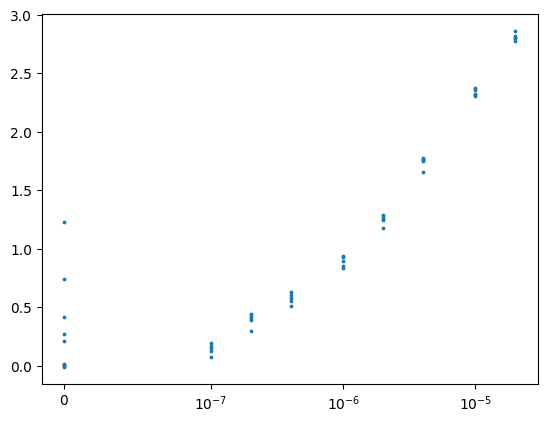

In [15]:
load_path = '/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/combined_ch0.csv'
df = pd.read_csv(load_path)
concentrations = 1e-6 * df['concentration'].to_numpy()
response = df['gain-200hz-ch5-aswift'].to_numpy()
plt.scatter(concentrations, response, s=3)
plt.xscale('symlog', linthresh=1e-7)
plt.show()